# Retry MediaPipe masks cho ?nh detect fail

Notebook n?y ch? x? l? c?c ?nh ?ang b? `uniform_fallback` trong b? mask MediaPipe. N? kh?ng s?a mask g?c m?c ??nh. Output ch?nh n?m trong `outputs/mediapipe_failed_retry_masks/` ?? review tr??c khi d?ng train.

? t??ng:

1. T?m c?c ?nh fail t? manifest ho?c t? mask `.npy` to?n 1.
2. Th? ch?y l?i MediaPipe v?i nhi?u bi?n th? nh?: gi?m confidence, t?ng detection size, equalize/gamma/CLAHE/sharpen/pad/flip/rotate nh?.
3. N?u detect ???c th? l?u mask m?i v?o `rescued_masks/`.
4. T?o `merged_mediapipe_region_masks/` b?ng c?ch copy mask g?c r?i ghi ?? c?c mask rescue. Config train s? tr? v?o th? m?c merged n?y.

In [5]:
import importlib


def mediapipe_capability():
    try:
        import mediapipe as mp
    except ImportError:
        return {"version": "not installed", "path": "unknown", "legacy": False, "tasks": False}

    legacy = False
    if hasattr(mp, "solutions") and hasattr(mp.solutions, "face_mesh"):
        legacy = True
    else:
        try:
            from mediapipe.python.solutions import face_mesh  # noqa: F401
            legacy = True
        except Exception:
            legacy = False

    tasks = False
    try:
        from mediapipe.tasks.python import vision
        tasks = hasattr(vision, "FaceLandmarker")
    except Exception:
        tasks = False

    return {
        "version": getattr(mp, "__version__", "unknown"),
        "path": getattr(mp, "__file__", "unknown"),
        "legacy": legacy,
        "tasks": tasks,
    }


mp_info = mediapipe_capability()
print("MediaPipe version:", mp_info["version"])
print("MediaPipe path:", mp_info["path"])
print("Legacy solutions.face_mesh:", mp_info["legacy"])
print("Tasks FaceLandmarker:", mp_info["tasks"])

if not mp_info["legacy"] and not mp_info["tasks"]:
    raise RuntimeError(
        "Notebook needs either legacy solutions.face_mesh or MediaPipe Tasks FaceLandmarker. "
        "Install/repair mediapipe in this kernel, then restart and rerun."
    )

MediaPipe version: 0.10.33
MediaPipe path: d:\DIP\.venv\Lib\site-packages\mediapipe\__init__.py
Legacy solutions.face_mesh: False
Tasks FaceLandmarker: True


In [6]:
import json
import math
import shutil
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageFilter, ImageOps


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "configs").exists() and (path / "scripts").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find repo root with configs/, scripts/, and src/.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo root:", ROOT)

Repo root: D:\DIP\Hydric_Graph_CNN


In [7]:
from types import SimpleNamespace
from urllib.request import urlretrieve

from scripts.precompute_mediapipe_region_masks import (
    REGION_LANDMARK_GROUPS,
    REGION_ORDER,
)

FACE_LANDMARKER_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/"
    "face_landmarker/float16/latest/face_landmarker.task"
)
FACE_LANDMARKER_MODEL_PATH = (
    ROOT / "outputs" / "mediapipe_failed_retry_masks" / "assets" / "face_landmarker.task"
)


class TasksFaceMeshAdapter:
    """Adapter de code cu van goi duoc .process(image)."""

    def __init__(self, min_detection_confidence=0.5, model_path=FACE_LANDMARKER_MODEL_PATH):
        import mediapipe as mp
        from mediapipe.tasks import python
        from mediapipe.tasks.python import vision

        self.mp = mp
        self.model_path = Path(model_path)
        self.model_path.parent.mkdir(parents=True, exist_ok=True)
        if not self.model_path.exists():
            print("Downloading FaceLandmarker model:", FACE_LANDMARKER_MODEL_URL)
            urlretrieve(FACE_LANDMARKER_MODEL_URL, self.model_path)
            print("Saved:", self.model_path)

        options = vision.FaceLandmarkerOptions(
            base_options=python.BaseOptions(model_asset_path=str(self.model_path)),
            running_mode=vision.RunningMode.IMAGE,
            num_faces=1,
            min_face_detection_confidence=float(min_detection_confidence),
            min_face_presence_confidence=float(min_detection_confidence),
            min_tracking_confidence=float(min_detection_confidence),
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)

    def process(self, image_rgb):
        image_rgb = np.ascontiguousarray(image_rgb.astype(np.uint8))
        mp_image = self.mp.Image(image_format=self.mp.ImageFormat.SRGB, data=image_rgb)
        result = self.landmarker.detect(mp_image)
        if not result.face_landmarks:
            return SimpleNamespace(multi_face_landmarks=None)
        face = SimpleNamespace(landmark=result.face_landmarks[0])
        return SimpleNamespace(multi_face_landmarks=[face])

    def close(self):
        self.landmarker.close()


def legacy_face_mesh_solution():
    import mediapipe as mp

    if hasattr(mp, "solutions") and hasattr(mp.solutions, "face_mesh"):
        return mp.solutions.face_mesh
    from mediapipe.python.solutions import face_mesh
    return face_mesh


def create_face_mesh_detector(min_detection_confidence=0.5):
    info = mediapipe_capability()
    if info["legacy"]:
        face_mesh_solution = legacy_face_mesh_solution()
        return face_mesh_solution.FaceMesh(
            static_image_mode=True,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=float(min_detection_confidence),
        )
    if info["tasks"]:
        return TasksFaceMeshAdapter(min_detection_confidence=min_detection_confidence)
    raise RuntimeError("No MediaPipe FaceMesh/FaceLandmarker API available in this kernel.")


EMOTION_DICT = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral",
}

REGION_COLORS = np.asarray(
    [
        [255, 216, 76],   # forehead
        [48, 213, 200],   # left eye
        [88, 142, 255],   # right eye
        [190, 115, 255],  # nose
        [255, 86, 97],    # mouth
        [96, 204, 112],   # chin
    ],
    dtype=np.float32,
) / 255.0

print("Regions:", REGION_ORDER)

Regions: ['forehead', 'left_eye', 'right_eye', 'nose', 'mouth', 'chin']


In [8]:
def first_existing(candidates, required_child=None):
    checked = []
    for candidate in candidates:
        path = Path(candidate)
        checked.append(str(path))
        if required_child is None:
            ok = path.exists()
        else:
            ok = (path / required_child).exists()
        if ok:
            return path
    raise FileNotFoundError("No candidate path exists:\n" + "\n".join(checked))


DATA_DIR = first_existing(
    [
        ROOT / "dataset" / "fer13-split",
        Path("/kaggle/input/datasets/doduyquynii/fer13-split/fer13-split"),
        Path("/kaggle/input/fer13-split/fer13-split"),
    ],
    required_child="train.csv",
)

SOURCE_MASK_ROOT = first_existing(
    [
        ROOT / "mediapipe_region_masks" / "mediapipe_region_masks",
        ROOT / "outputs" / "mediapipe_region_masks",
        Path("/kaggle/working/outputs/mediapipe_region_masks"),
        Path("/kaggle/input/datasets/lhongphuc3/mediapipe-mask-datasets/mediapipe_region_masks"),
        Path("/kaggle/input/mediapipe_mask_datasets/mediapipe_region_masks"),
        Path("/kaggle/input/fer2013-mediapipe-region-masks/mediapipe_region_masks"),
    ],
    required_child="train",
)

OUTPUT_DIR = ROOT / "outputs" / "mediapipe_failed_retry_masks"
RESCUED_MASK_ROOT = OUTPUT_DIR / "rescued_masks"
MERGED_MASK_ROOT = OUTPUT_DIR / "merged_mediapipe_region_masks"
PREVIEW_ROOT = OUTPUT_DIR / "previews"
TRAIN_MANIFEST_CSV = ROOT / "outputs" / "mediapipe_train_detection_folders" / "train_mediapipe_detection_manifest.csv"

# Mac dinh chi rescue train vi user dang noi 2,248 anh train fail.
# Neu muon rescue ca val/test thi doi thanh ["train", "val", "test"].
SPLITS_TO_RETRY = ["train"]

# Thu muc merged nen co du train/val/test de dung truc tiep cho config train/eval.
SPLITS_TO_COPY_INTO_MERGED = ["train", "val", "test"]

MASK_SIZE = 7
SIGMA = 1.25
SAVE_DTYPE = np.float16
UNIFORM_ATOL = 1e-4

# Thu tu nay uu tien bien the nhe truoc, bien the hinh hoc sau.
CONFIDENCES = [0.35, 0.25, 0.15]
DETECTION_SIZES = [224, 256, 320]
METHODS = [
    "raw",
    "equalize",
    "gamma_0_70",
    "gamma_0_55",
    "clahe",
    "sharpen",
    "pad8",
    "hflip",
    "rot_m10",
    "rot_p10",
]

MAX_SAMPLES = None      # dat so nho nhu 100 de smoke-test truoc
LOG_EVERY = 100
SAVE_PREVIEWS = True
MAX_PREVIEWS_PER_STATUS = 200
BUILD_MERGED_MASK_DIR = True
OVERWRITE_MERGED_FILES = True
PACKAGE_ZIP = True

print("DATA_DIR:", DATA_DIR)
print("SOURCE_MASK_ROOT:", SOURCE_MASK_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

FileNotFoundError: No candidate path exists:
D:\DIP\Hydric_Graph_CNN\dataset\fer13-split
\kaggle\input\datasets\doduyquynii\fer13-split\fer13-split
\kaggle\input\fer13-split\fer13-split

In [ ]:
def pixels_to_gray(pixels):
    values = np.fromstring(str(pixels), sep=" ", dtype=np.uint8)
    if values.size != 48 * 48:
        raise ValueError(f"Expected 2304 pixels, got {values.size}")
    return values.reshape(48, 48)


def pil_bilinear():
    try:
        return Image.Resampling.BILINEAR
    except AttributeError:
        return Image.BILINEAR


def resize_gray(gray, size):
    if gray.shape == (size, size):
        return gray.astype(np.uint8)
    return np.asarray(Image.fromarray(gray.astype(np.uint8)).resize((size, size), pil_bilinear()))


def gray_to_rgb(gray):
    return np.ascontiguousarray(np.repeat(gray[..., None], 3, axis=2).astype(np.uint8))


def is_uniform_mask(mask, atol=UNIFORM_ATOL):
    mask = np.asarray(mask, dtype=np.float32)
    if mask.ndim != 3:
        return False
    return bool(np.allclose(mask, 1.0, atol=atol))


def mask_path_for(root, split, row_index):
    return Path(root) / split / f"{int(row_index):06d}.npy"


def render_gaussian_masks_from_xy(landmark_xy, mask_size=MASK_SIZE, sigma=SIGMA, dtype=SAVE_DTYPE):
    yy, xx = np.meshgrid(
        np.arange(mask_size, dtype=np.float32),
        np.arange(mask_size, dtype=np.float32),
        indexing="ij",
    )
    masks = np.zeros((len(REGION_ORDER), mask_size, mask_size), dtype=np.float32)
    landmark_xy = np.asarray(landmark_xy, dtype=np.float32)
    landmark_xy = np.clip(landmark_xy, 0.0, 1.0)

    for region_idx, region_name in enumerate(REGION_ORDER):
        indices = REGION_LANDMARK_GROUPS[region_name]
        pts = landmark_xy[indices]
        cx = float(pts[:, 0].mean() * (mask_size - 1))
        cy = float(pts[:, 1].mean() * (mask_size - 1))
        dist_sq = (xx - cx) ** 2 + (yy - cy) ** 2
        mask = np.exp(-dist_sq / (2.0 * sigma ** 2))
        mask = mask / max(float(mask.max()), 1e-8)
        masks[region_idx] = mask

    return masks.astype(dtype)


def safe_json_dump(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")


def emotion_name(value):
    return EMOTION_DICT.get(int(value), str(value))

In [ ]:
def gamma_adjust(gray, gamma):
    arr = gray.astype(np.float32) / 255.0
    arr = np.power(np.clip(arr, 0.0, 1.0), float(gamma))
    return np.clip(arr * 255.0, 0, 255).astype(np.uint8)


def clahe_adjust(gray):
    try:
        import cv2
    except ImportError:
        return None
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    return clahe.apply(gray.astype(np.uint8))


def sharpen_gray(gray):
    pil = Image.fromarray(gray.astype(np.uint8))
    pil = pil.filter(ImageFilter.UnsharpMask(radius=1.0, percent=120, threshold=2))
    return np.asarray(pil, dtype=np.uint8)


def rotate_gray(gray, angle_degrees):
    fill = int(np.median(gray))
    pil = Image.fromarray(gray.astype(np.uint8))
    try:
        resample = Image.Resampling.BILINEAR
    except AttributeError:
        resample = Image.BILINEAR
    return np.asarray(
        pil.rotate(angle_degrees, resample=resample, expand=False, fillcolor=fill),
        dtype=np.uint8,
    )


def identity_mapper(x, y):
    return float(x), float(y)


def make_rotation_mapper(angle_degrees, width=48, height=48):
    theta = math.radians(-float(angle_degrees))
    cos_t = math.cos(theta)
    sin_t = math.sin(theta)
    cx = (width - 1) / 2.0
    cy = (height - 1) / 2.0

    def mapper(x, y):
        px = float(x) * (width - 1)
        py = float(y) * (height - 1)
        dx = px - cx
        dy = py - cy
        ox = cos_t * dx - sin_t * dy + cx
        oy = sin_t * dx + cos_t * dy + cy
        return ox / (width - 1), oy / (height - 1)

    return mapper


def make_pad_mapper(pad, original_size=48):
    padded_size = original_size + 2 * int(pad)

    def mapper(x, y):
        px = float(x) * (padded_size - 1)
        py = float(y) * (padded_size - 1)
        ox = px - pad
        oy = py - pad
        return ox / (original_size - 1), oy / (original_size - 1)

    return mapper


def preprocess_variant(gray, method):
    method = method.lower()
    if method == "raw":
        return gray.astype(np.uint8), identity_mapper
    if method == "equalize":
        return np.asarray(ImageOps.equalize(Image.fromarray(gray.astype(np.uint8)))), identity_mapper
    if method == "gamma_0_70":
        return gamma_adjust(gray, 0.70), identity_mapper
    if method == "gamma_0_55":
        return gamma_adjust(gray, 0.55), identity_mapper
    if method == "clahe":
        adjusted = clahe_adjust(gray)
        return (adjusted, identity_mapper) if adjusted is not None else (None, None)
    if method == "sharpen":
        return sharpen_gray(gray), identity_mapper
    if method == "pad8":
        pad = 8
        padded = np.pad(gray.astype(np.uint8), ((pad, pad), (pad, pad)), mode="edge")
        return padded, make_pad_mapper(pad)
    if method == "hflip":
        def mapper(x, y):
            return 1.0 - float(x), float(y)
        return np.fliplr(gray.astype(np.uint8)), mapper
    if method == "rot_m10":
        return rotate_gray(gray, -10), make_rotation_mapper(-10)
    if method == "rot_p10":
        return rotate_gray(gray, 10), make_rotation_mapper(10)
    raise ValueError(f"Unknown method: {method}")

In [ ]:
def detect_masks_for_variant(face_mesh, gray, method, detection_size):
    transformed, mapper = preprocess_variant(gray, method)
    if transformed is None:
        return None

    resized = resize_gray(transformed, int(detection_size))
    rgb = gray_to_rgb(resized)
    rgb.flags.writeable = False
    result = face_mesh.process(rgb)
    if not result.multi_face_landmarks:
        return None

    face = result.multi_face_landmarks[0]
    landmark_xy = []
    for landmark in face.landmark:
        x, y = mapper(float(landmark.x), float(landmark.y))
        landmark_xy.append((x, y))

    masks = render_gaussian_masks_from_xy(landmark_xy)
    if is_uniform_mask(masks):
        return None
    return masks


def retry_one_image(face_mesh_by_confidence, pixels):
    gray = pixels_to_gray(pixels)
    for confidence in CONFIDENCES:
        face_mesh = face_mesh_by_confidence[confidence]
        for detection_size in DETECTION_SIZES:
            for method in METHODS:
                masks = detect_masks_for_variant(face_mesh, gray, method, detection_size)
                if masks is not None:
                    return masks, {
                        "method": method,
                        "confidence": confidence,
                        "detection_size": detection_size,
                    }
    return None, {"method": None, "confidence": None, "detection_size": None}

In [ ]:
def resize_mask(mask, size):
    mask = np.asarray(mask, dtype=np.float32)
    pil = Image.fromarray(mask, mode="F")
    return np.asarray(pil.resize((size, size), pil_bilinear()), dtype=np.float32)


def combined_overlay(gray, masks, size=112, alpha=0.55):
    base = resize_gray(gray, size).astype(np.float32) / 255.0
    rgb = np.repeat(base[..., None], 3, axis=2)
    overlay = rgb.copy()
    for region_idx, color in enumerate(REGION_COLORS):
        mask = resize_mask(masks[region_idx], size)
        mask = np.clip(mask, 0.0, 1.0)[..., None]
        overlay = np.clip(overlay * (1.0 - alpha * mask) + color * alpha * mask, 0.0, 1.0)
    return (overlay * 255).astype(np.uint8)


def make_retry_preview(gray, masks, title, out_path, size=112):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    original = resize_gray(gray, size)
    original_rgb = np.repeat(original[..., None], 3, axis=2)

    if masks is None:
        overlay = original_rgb
    else:
        overlay = combined_overlay(gray, masks, size=size)

    title_height = 34
    canvas = np.full((size + title_height, size * 2, 3), 255, dtype=np.uint8)
    canvas[title_height:, :size] = original_rgb
    canvas[title_height:, size:] = overlay

    try:
        import cv2
        cv2.putText(canvas, "original", (4, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (20, 20, 20), 1, cv2.LINE_AA)
        cv2.putText(canvas, title[:38], (size + 4, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (20, 20, 20), 1, cv2.LINE_AA)
    except ImportError:
        pass

    Image.fromarray(canvas).save(out_path)
    return out_path

In [ ]:
def read_split_df(split):
    csv_path = DATA_DIR / f"{split}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    return pd.read_csv(csv_path, usecols=["emotion", "pixels"])


def failed_indices_from_manifest(split):
    if split != "train" or not TRAIN_MANIFEST_CSV.exists():
        return None
    manifest = pd.read_csv(TRAIN_MANIFEST_CSV, usecols=["row_index", "status"])
    failed = manifest.loc[manifest["status"].eq("detect_failed"), "row_index"].astype(int).tolist()
    return failed


def failed_indices_from_masks(split):
    split_mask_dir = SOURCE_MASK_ROOT / split
    if not split_mask_dir.exists():
        raise FileNotFoundError(split_mask_dir)
    failed = []
    for mask_path in sorted(split_mask_dir.glob("*.npy")):
        try:
            mask = np.load(mask_path)
        except Exception:
            continue
        if is_uniform_mask(mask):
            failed.append(int(mask_path.stem))
    return failed


def get_failed_indices(split):
    indices = failed_indices_from_manifest(split)
    source = "manifest"
    if indices is None:
        indices = failed_indices_from_masks(split)
        source = "mask_scan"
    if MAX_SAMPLES is not None:
        indices = indices[: int(MAX_SAMPLES)]
    print(f"[{split}] failed indices from {source}: {len(indices)}")
    return indices


for split in SPLITS_TO_RETRY:
    _ = get_failed_indices(split)

[train] failed indices from manifest: 2248


In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESCUED_MASK_ROOT.mkdir(parents=True, exist_ok=True)
PREVIEW_ROOT.mkdir(parents=True, exist_ok=True)

face_mesh_by_confidence = {}
for confidence in CONFIDENCES:
    face_mesh_by_confidence[confidence] = create_face_mesh_detector(
        min_detection_confidence=float(confidence)
    )

records = []
summary_counter = Counter()
preview_counter = Counter()
start_time = time.time()

try:
    for split in SPLITS_TO_RETRY:
        df = read_split_df(split)
        failed_indices = get_failed_indices(split)
        split_rescue_dir = RESCUED_MASK_ROOT / split
        split_rescue_dir.mkdir(parents=True, exist_ok=True)

        for position, row_index in enumerate(failed_indices, start=1):
            row = df.iloc[int(row_index)]
            emotion = int(row["emotion"])
            gray = pixels_to_gray(row["pixels"])
            masks, info = retry_one_image(face_mesh_by_confidence, row["pixels"])

            if masks is not None:
                status = "rescued"
                out_mask = split_rescue_dir / f"{int(row_index):06d}.npy"
                np.save(out_mask, masks.astype(SAVE_DTYPE))
            else:
                status = "still_failed"
                out_mask = None

            summary_counter[(split, status)] += 1

            preview_file = None
            if SAVE_PREVIEWS and preview_counter[(split, status)] < MAX_PREVIEWS_PER_STATUS:
                preview_counter[(split, status)] += 1
                preview_file = PREVIEW_ROOT / split / status / f"{int(row_index):06d}_{emotion_name(emotion)}.png"
                title = status if masks is None else f"{info['method']} c={info['confidence']} s={info['detection_size']}"
                make_retry_preview(gray, masks, title, preview_file)

            records.append(
                {
                    "split": split,
                    "row_index": int(row_index),
                    "emotion": emotion,
                    "emotion_name": emotion_name(emotion),
                    "status": status,
                    "method": info.get("method"),
                    "confidence": info.get("confidence"),
                    "detection_size": info.get("detection_size"),
                    "source_mask_file": str(mask_path_for(SOURCE_MASK_ROOT, split, row_index)),
                    "rescued_mask_file": str(out_mask) if out_mask is not None else "",
                    "preview_file": str(preview_file) if preview_file is not None else "",
                }
            )

            if position % LOG_EVERY == 0 or position == len(failed_indices):
                rescued = summary_counter[(split, "rescued")]
                still_failed = summary_counter[(split, "still_failed")]
                elapsed = time.time() - start_time
                print(
                    f"[{split}] {position}/{len(failed_indices)} | "
                    f"rescued={rescued}, still_failed={still_failed}, elapsed={elapsed/60:.1f} min"
                )
finally:
    for face_mesh in face_mesh_by_confidence.values():
        face_mesh.close()

manifest_df = pd.DataFrame(records)
manifest_path = OUTPUT_DIR / "retry_manifest.csv"
manifest_df.to_csv(manifest_path, index=False, encoding="utf-8-sig")

summary = {
    "data_dir": str(DATA_DIR),
    "source_mask_root": str(SOURCE_MASK_ROOT),
    "rescued_mask_root": str(RESCUED_MASK_ROOT),
    "splits_to_retry": SPLITS_TO_RETRY,
    "mask_shape": [len(REGION_ORDER), MASK_SIZE, MASK_SIZE],
    "sigma": SIGMA,
    "confidences": CONFIDENCES,
    "detection_sizes": DETECTION_SIZES,
    "methods": METHODS,
    "counts": {f"{split}_{status}": int(count) for (split, status), count in summary_counter.items()},
    "manifest": str(manifest_path),
}
safe_json_dump(summary, OUTPUT_DIR / "retry_summary.json")

print("Saved manifest:", manifest_path)
print(json.dumps(summary, indent=2, ensure_ascii=False))

[train] failed indices from manifest: 2248
[train] 100/2248 | rescued=83, still_failed=17, elapsed=0.6 min
[train] 200/2248 | rescued=165, still_failed=35, elapsed=1.4 min
[train] 300/2248 | rescued=251, still_failed=49, elapsed=2.3 min
[train] 400/2248 | rescued=331, still_failed=69, elapsed=3.3 min
[train] 500/2248 | rescued=412, still_failed=88, elapsed=4.1 min
[train] 600/2248 | rescued=493, still_failed=107, elapsed=4.7 min
[train] 700/2248 | rescued=577, still_failed=123, elapsed=5.4 min
[train] 800/2248 | rescued=660, still_failed=140, elapsed=5.9 min
[train] 900/2248 | rescued=749, still_failed=151, elapsed=6.3 min
[train] 1000/2248 | rescued=841, still_failed=159, elapsed=6.8 min
[train] 1100/2248 | rescued=922, still_failed=178, elapsed=7.7 min
[train] 1200/2248 | rescued=1004, still_failed=196, elapsed=8.5 min
[train] 1300/2248 | rescued=1087, still_failed=213, elapsed=9.6 min
[train] 1400/2248 | rescued=1167, still_failed=233, elapsed=10.1 min
[train] 1500/2248 | rescued=12

In [ ]:
if len(records) > 0:
    display(manifest_df.groupby(["split", "status"]).size().rename("count").reset_index())
    rescued_methods = manifest_df.loc[manifest_df["status"].eq("rescued")]
    if not rescued_methods.empty:
        display(rescued_methods.groupby(["method", "confidence", "detection_size"]).size().rename("count").reset_index().sort_values("count", ascending=False))
else:
    print("No retry records. Check SPLITS_TO_RETRY and mask source paths.")

,split,status,count
0,train,rescued,1903
1,train,still_failed,345


,method,confidence,detection_size,count
46,raw,0.35,224.0,1041
13,equalize,0.35,224.0,131
40,pad8,0.35,224.0,111
31,hflip,0.35,224.0,81
24,gamma_0_70,0.35,224.0,65
...,...,...,...,...
16,gamma_0_55,0.15,224.0,1
47,raw,0.35,256.0,1
48,raw,0.35,320.0,1
58,rot_p10,0.15,320.0,1


In [ ]:
def copy_original_masks_to_merged():
    if not BUILD_MERGED_MASK_DIR:
        print("BUILD_MERGED_MASK_DIR=False, skip.")
        return

    MERGED_MASK_ROOT.mkdir(parents=True, exist_ok=True)
    copied = 0
    skipped = 0
    overwritten = 0

    for split in SPLITS_TO_COPY_INTO_MERGED:
        src_dir = SOURCE_MASK_ROOT / split
        dst_dir = MERGED_MASK_ROOT / split
        dst_dir.mkdir(parents=True, exist_ok=True)
        if not src_dir.exists():
            print("Missing source split, skip:", src_dir)
            continue
        for src_file in sorted(src_dir.glob("*.npy")):
            dst_file = dst_dir / src_file.name
            if dst_file.exists() and not OVERWRITE_MERGED_FILES:
                skipped += 1
                continue
            shutil.copy2(src_file, dst_file)
            copied += 1

    for rescued_file in sorted(RESCUED_MASK_ROOT.glob("*/*.npy")):
        split = rescued_file.parent.name
        dst_file = MERGED_MASK_ROOT / split / rescued_file.name
        dst_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(rescued_file, dst_file)
        overwritten += 1

    print("Merged mask root:", MERGED_MASK_ROOT)
    print(f"Copied original={copied}, skipped={skipped}, rescued_overwrite={overwritten}")


copy_original_masks_to_merged()

Merged mask root: D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\outputs\mediapipe_failed_retry_masks\merged_mediapipe_region_masks
Copied original=35887, skipped=0, rescued_overwrite=1903


In [ ]:
if PACKAGE_ZIP and MERGED_MASK_ROOT.exists():
    zip_path = shutil.make_archive(
        str(OUTPUT_DIR / "merged_mediapipe_region_masks"),
        "zip",
        root_dir=MERGED_MASK_ROOT.parent,
        base_dir=MERGED_MASK_ROOT.name,
    )
    print("Saved zip:", zip_path)

print("\nUse this local mask_dir in config:")
print(MERGED_MASK_ROOT)
print("\nYAML override example:")
print(f"""model:\n  mask_dir: \"{MERGED_MASK_ROOT.as_posix()}\"\n\ndata:\n  mask_dir: \"{MERGED_MASK_ROOT.as_posix()}\"""")

Saved zip: D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\outputs\mediapipe_failed_retry_masks\merged_mediapipe_region_masks.zip

Use this local mask_dir in config:
D:\HocTap\Phân tích  và xử lý ảnh\sgu-2026-facial-expression-recognition\outputs\mediapipe_failed_retry_masks\merged_mediapipe_region_masks

YAML override example:
model:
  mask_dir: "D:/HocTap/Phân tích  và xử lý ảnh/sgu-2026-facial-expression-recognition/outputs/mediapipe_failed_retry_masks/merged_mediapipe_region_masks"

data:
  mask_dir: "D:/HocTap/Phân tích  và xử lý ảnh/sgu-2026-facial-expression-recognition/outputs/mediapipe_failed_retry_masks/merged_mediapipe_region_masks"


000023_angry.png


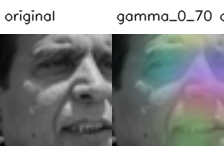

000049_fear.png


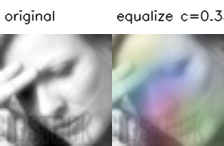

000068_angry.png


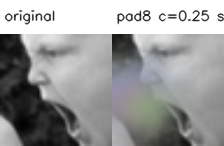

000083_neutral.png


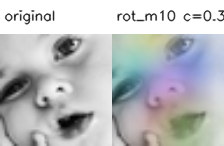

000115_sad.png


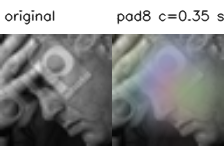

000123_angry.png


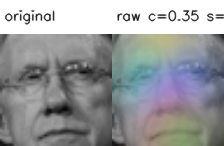

000125_happy.png


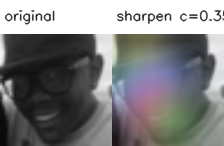

000131_fear.png


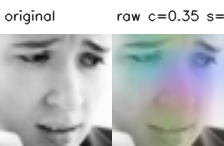

In [ ]:
preview_files = sorted((PREVIEW_ROOT / "train" / "rescued").glob("*.png"))[:8]
if preview_files:
    for path in preview_files:
        print(path.name)
        display(Image.open(path))
else:
    print("No rescued preview yet. Run the retry cell first, or check still_failed previews.")